In [2]:
from dotenv import load_dotenv
from core.validation import get_valid_image_number
import cv2 as cv
import os


### Setup ###
# Load variables from .env file
load_dotenv()

# Base Path for image folder
base_mask_folder: str = os.getenv("BASE_MASK_FOLDER")
img_number: str = get_valid_image_number()
mask_path: str = os.path.join(base_mask_folder, f"{img_number}.png")

In [ ]:
### Image ###
# Load image
bgr_img = cv.imread(mask_path)
# Show image for the user
cv.imshow("BGR Image", bgr_img)
# Wait user press keys to close images
cv.waitKey(0)
# Close all windows
cv.destroyAllWindows()

In [1]:
from core.validation import get_valid_image_number
from dotenv import load_dotenv
from numpy import ndarray
import numpy as np
import os


### Setup ###
# Load variables from .env file
load_dotenv()

# Base Path for image folder
numpy_folder: str = os.getenv("NUMPY_FOLDER")

# Define numpy file path
img_number: str = get_valid_image_number()
numpy_file_path: str = os.path.join(numpy_folder, f"{img_number}.npy")

# Load numpy file
numpy_file = np.load(numpy_file_path)

[[[0]
  [0]
  [0]
  ...
  [0]
  [0]
  [0]]

 [[0]
  [0]
  [0]
  ...
  [0]
  [0]
  [0]]

 [[0]
  [0]
  [0]
  ...
  [0]
  [0]
  [0]]

 ...

 [[0]
  [0]
  [0]
  ...
  [0]
  [0]
  [0]]

 [[0]
  [0]
  [0]
  ...
  [0]
  [0]
  [0]]

 [[0]
  [0]
  [0]
  ...
  [0]
  [0]
  [0]]]


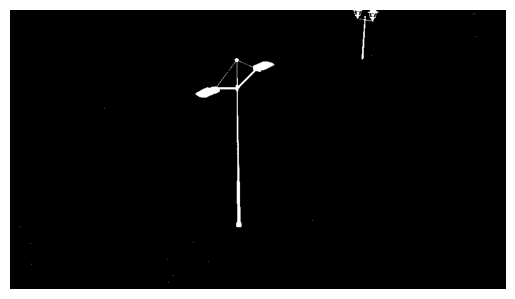

In [6]:
# Split numpy file in a list of masks
masks: list[ndarray] = np.split(ary=numpy_file, indices_or_sections=18, axis=2)

# Test: Accessing a mask
# print(masks[0])

import matplotlib.pyplot as plt

plt.imshow(X=masks[0], cmap="gray", interpolation="antialiased")
plt.axis("off")
plt.show()

In [5]:
import cv2 as cv

# Base Path for image folder
recovered_img_folder: str = os.getenv("RECOVERED_IMG_FOLDER")
for index, mask in enumerate(masks):
    output_file: str = os.path.join(recovered_img_folder, f"recovered_mask_{index+1}_img_{img_number}.png")
    cv.imwrite(output_file, mask)